## Exam Timetabling System using Graph Coloring

### Algorithms:
#### 1. Greedy Coloring
#### 2. DSATUR Coloring

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import random

plt.rcParams["figure.figsize"] = (12,8)

### Generate Dataset

In [5]:
courses = [
    "Math","Physics","Chemistry","Biology","English",
    "Programming","Databases","AI","Networks","Security",
    "Calculus","Statistics","Economics","Accounting",
    "Marketing","Operating Systems","Cloud","IoT",
    "Machine Learning","Data Mining"
]

students = []

for student in range(1,101):
    selected = random.sample(courses, random.randint(4,6))

    for course in selected:
        students.append([student, course])

df = pd.DataFrame(students, columns=["StudentID","Course"])

df.head()

,StudentID,Course
0,1,Statistics
1,1,Biology
2,1,Economics
3,1,Accounting
4,1,Physics


### Build Conflict Graph

In [6]:
G = nx.Graph()

for course in courses:
    G.add_node(course)

for student in df["StudentID"].unique():

    enrolled = df[df["StudentID"] == student]["Course"].tolist()

    for c1, c2 in combinations(enrolled,2):
        G.add_edge(c1,c2)

print("Courses:", G.number_of_nodes())
print("Conflicts:", G.number_of_edges())

Courses: 20
Conflicts: 189


### Visualize Graph

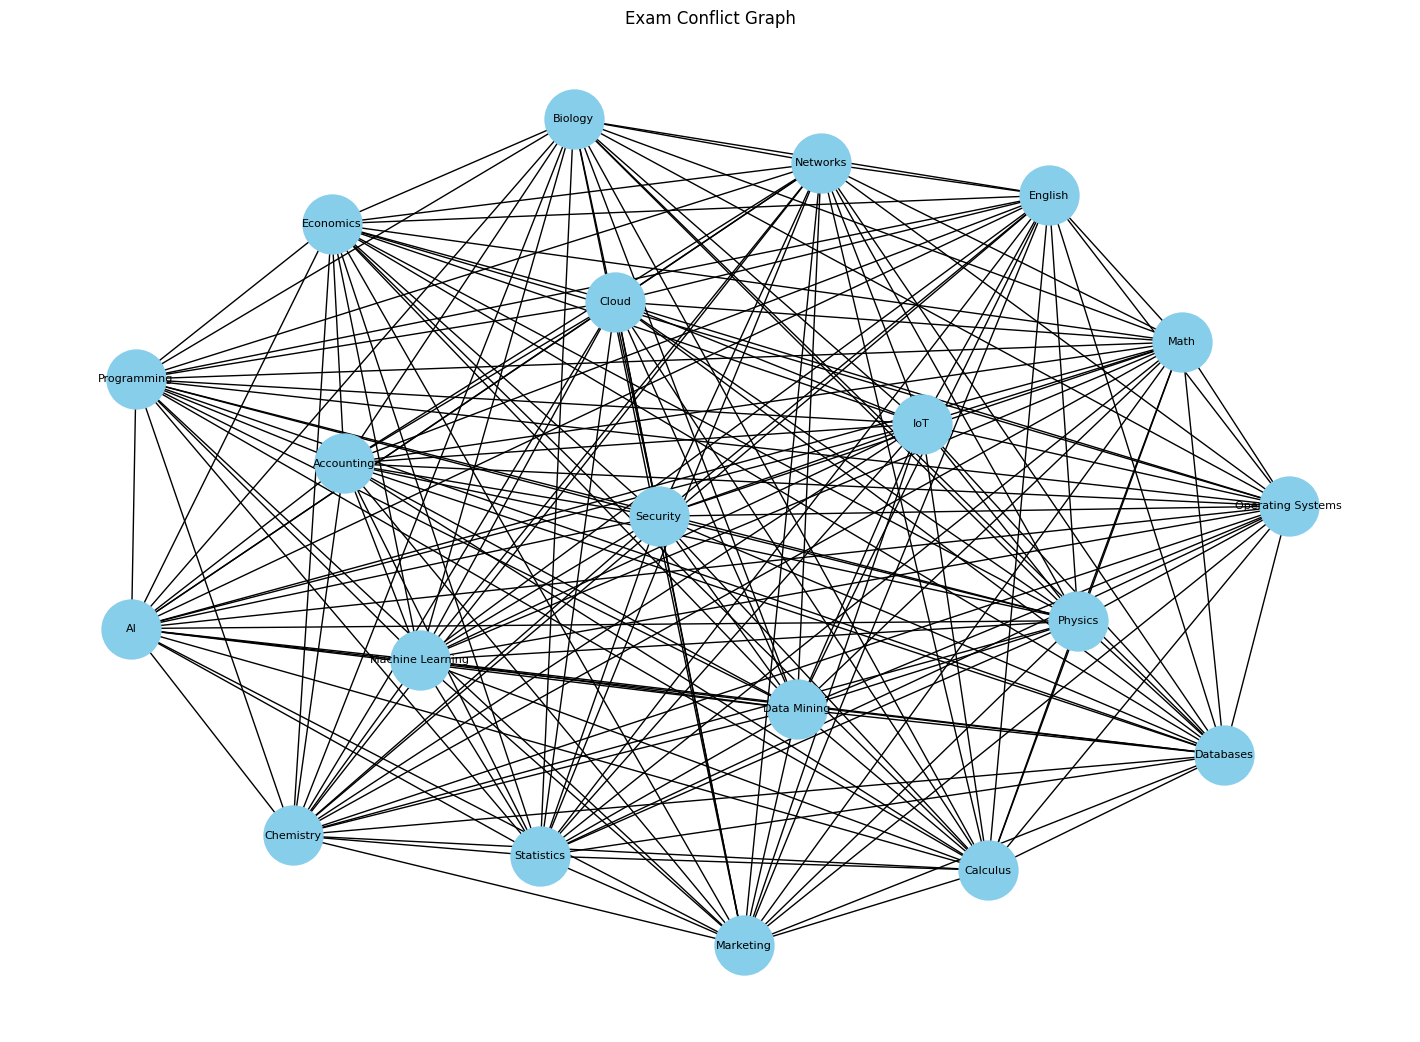

In [7]:
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=1800,
    font_size=8
)

plt.title("Exam Conflict Graph")
plt.show()

### Greedy Coloring

In [8]:
greedy_colors = nx.coloring.greedy_color(
    G,
    strategy="largest_first"
)

greedy_slots = max(greedy_colors.values()) + 1

print("Greedy Timeslots:", greedy_slots)

Greedy Timeslots: 19


### DSATUR Coloring

In [9]:
dsatur_colors = nx.coloring.greedy_color(
    G,
    strategy="DSATUR"
)

dsatur_slots = max(dsatur_colors.values()) + 1

print("DSATUR Timeslots:", dsatur_slots)

DSATUR Timeslots: 19


### Comparison

In [10]:
comparison = pd.DataFrame({
    "Algorithm":["Greedy","DSATUR"],
    "Timeslots":[greedy_slots, dsatur_slots]
})

comparison

,Algorithm,Timeslots
0,Greedy,19
1,DSATUR,19


### Visualize Comparison

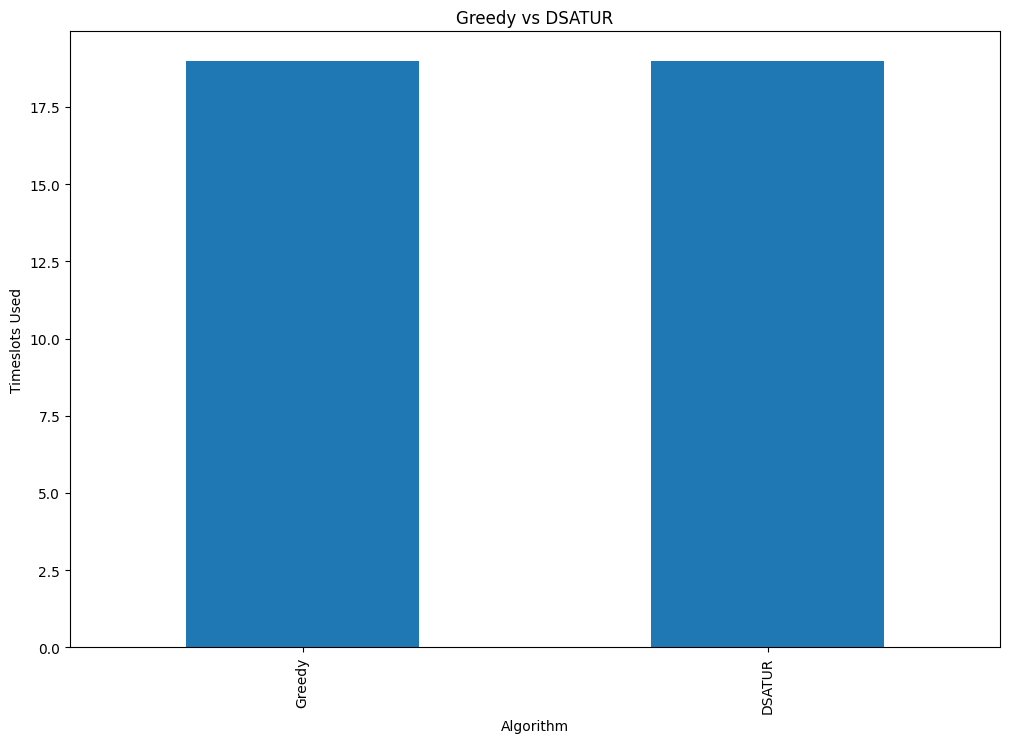

In [11]:
comparison.plot(
    x="Algorithm",
    y="Timeslots",
    kind="bar",
    legend=False
)

plt.ylabel("Timeslots Used")
plt.title("Greedy vs DSATUR")
plt.show()

### Generate Timetable

In [12]:
days = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

periods = [1,2,3]

schedule_slots = []

for d in days:
    for p in periods:
        schedule_slots.append(f"{d} - Period {p}")

timetable = []

for exam,color in dsatur_colors.items():

    timetable.append([
        exam,
        schedule_slots[color]
    ])

timetable_df = pd.DataFrame(
    timetable,
    columns=["Exam","Scheduled Slot"]
)

timetable_df.sort_values(
    by="Scheduled Slot"
)

,Exam,Scheduled Slot
15,IoT,Friday - Period 1
16,Machine Learning,Friday - Period 2
17,Data Mining,Friday - Period 3
3,English,Monday - Period 1
4,Programming,Monday - Period 2
5,Databases,Monday - Period 3
19,Cloud,Saturday - Period 1
18,Biology,Saturday - Period 1
0,Math,Sunday - Period 1
1,Physics,Sunday - Period 2


### Colorized DSATUR Graph

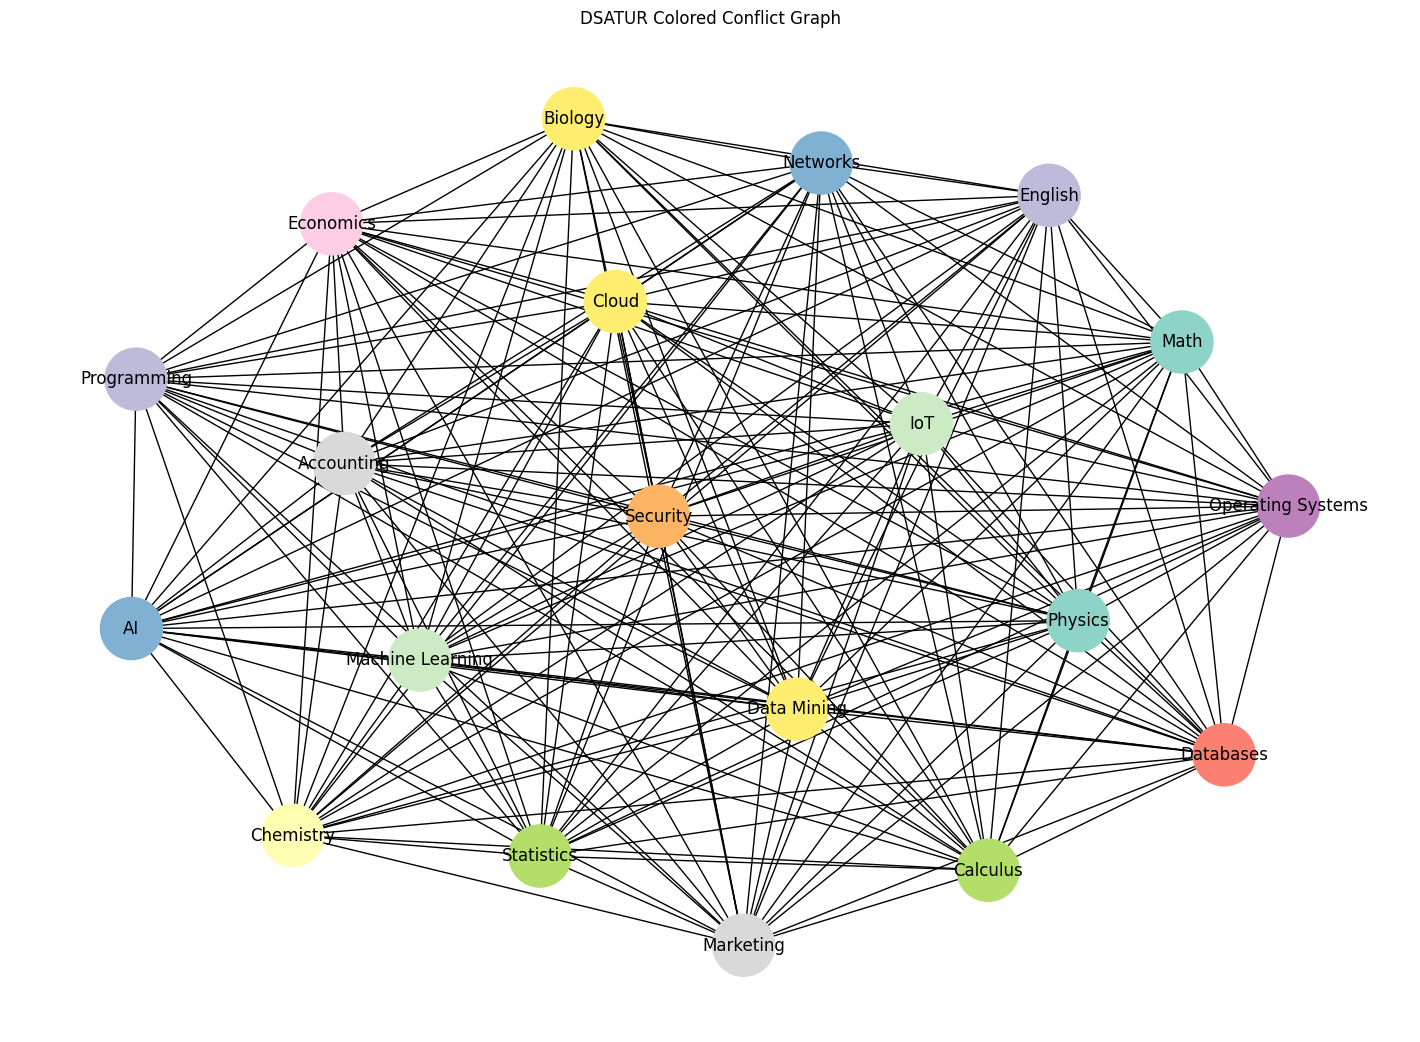

In [13]:
color_map = [dsatur_colors[node] for node in G.nodes()]

plt.figure(figsize=(14,10))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    cmap=plt.cm.Set3,
    node_size=2000
)

plt.title("DSATUR Colored Conflict Graph")
plt.show()